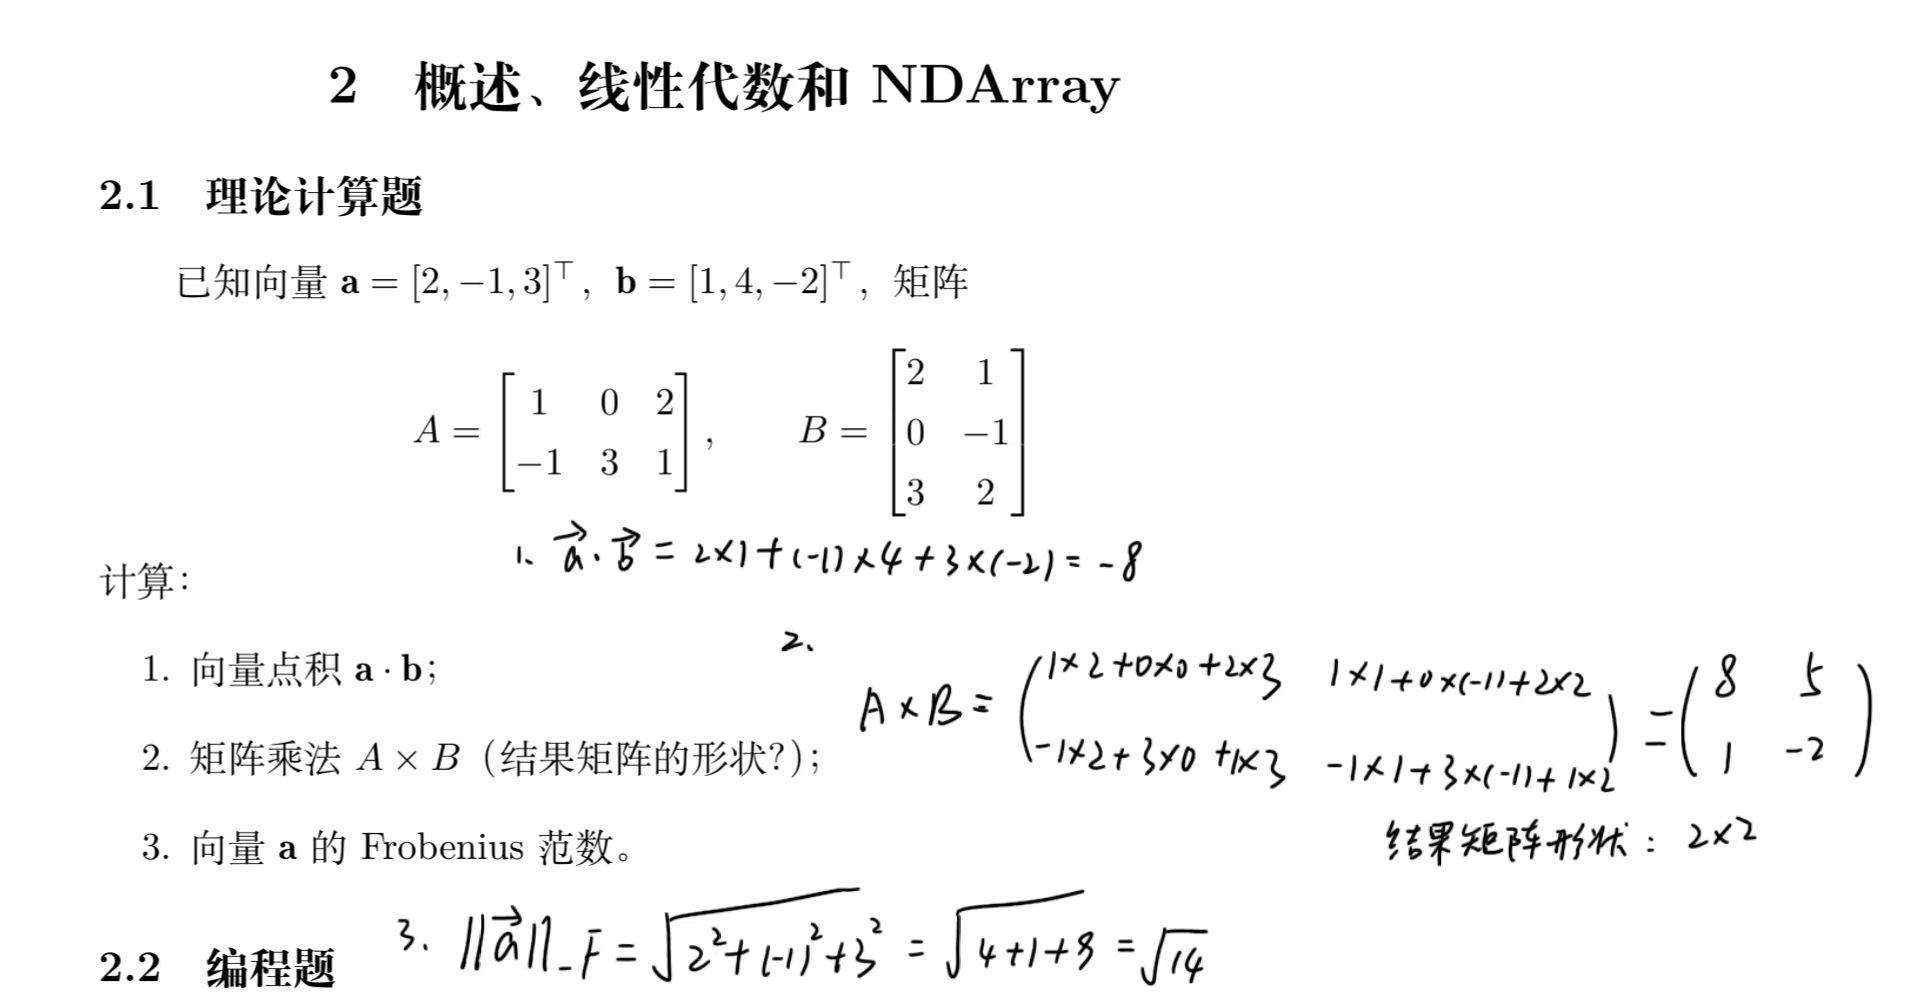

2.2 编程题
使用 NumPy（或 MXNet / PyTorch/TensorFlow）完成以下任务：
1. 创建一个形状为 3 × 4 的随机矩阵 X，元素服从标准正态分布。
2. 创建一个形状为 4 × 2 的全 1 矩阵 Y 。
3. 计算矩阵乘法 Z = X × Y 。
4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素。
5. 计算 Z 的 Frobenius 范数。

In [6]:
import numpy as np
X = np.random.randn(3, 4)
Y = np.ones((4, 2))
Z = X @ Y

print("Z[0,1] =", Z[0, 1])
print("Z第2行 =", Z[1, :])
print("Z的F范数 =", np.linalg.norm(Z, 'fro'))

Z[0,1] = 1.1308357723493416
Z第2行 = [-0.84777077 -0.84777077]
Z的F范数 = 2.3421800784045024


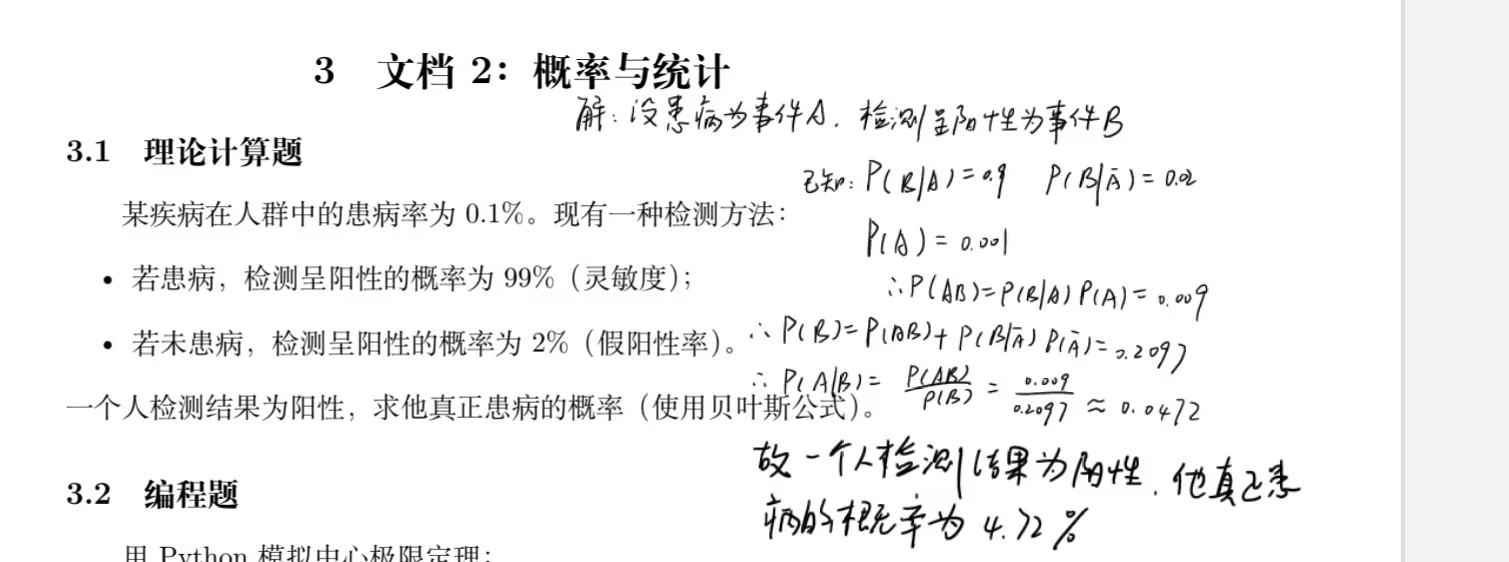

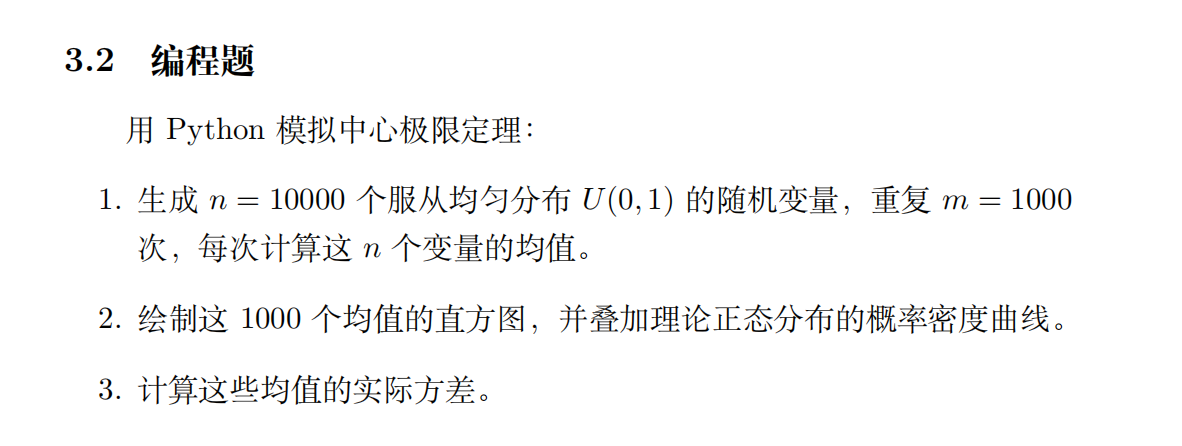

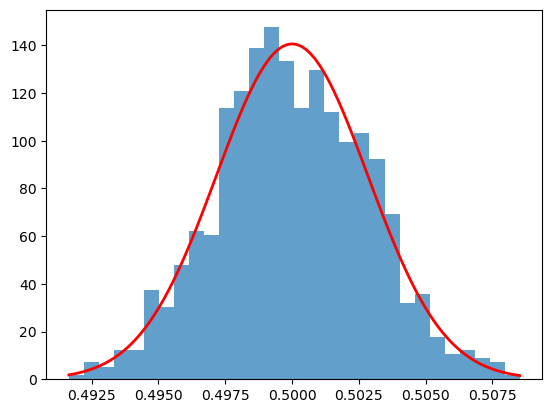

均值的方差 = 8.051805430036408e-06


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

n = 10000
m = 1000
means = []

for _ in range(m):
    sample = np.random.uniform(0, 1, n)
    means.append(sample.mean())

# 画直方图
plt.hist(means, bins=30, density=True, alpha=0.7)

# 理论正态分布拟合
mu, std = np.mean(means), np.std(means)
x = np.linspace(min(means), max(means), 100)
plt.plot(x, norm.pdf(x, mu, std), 'r', linewidth=2)

plt.show()
print("均值的方差 =", np.var(means))

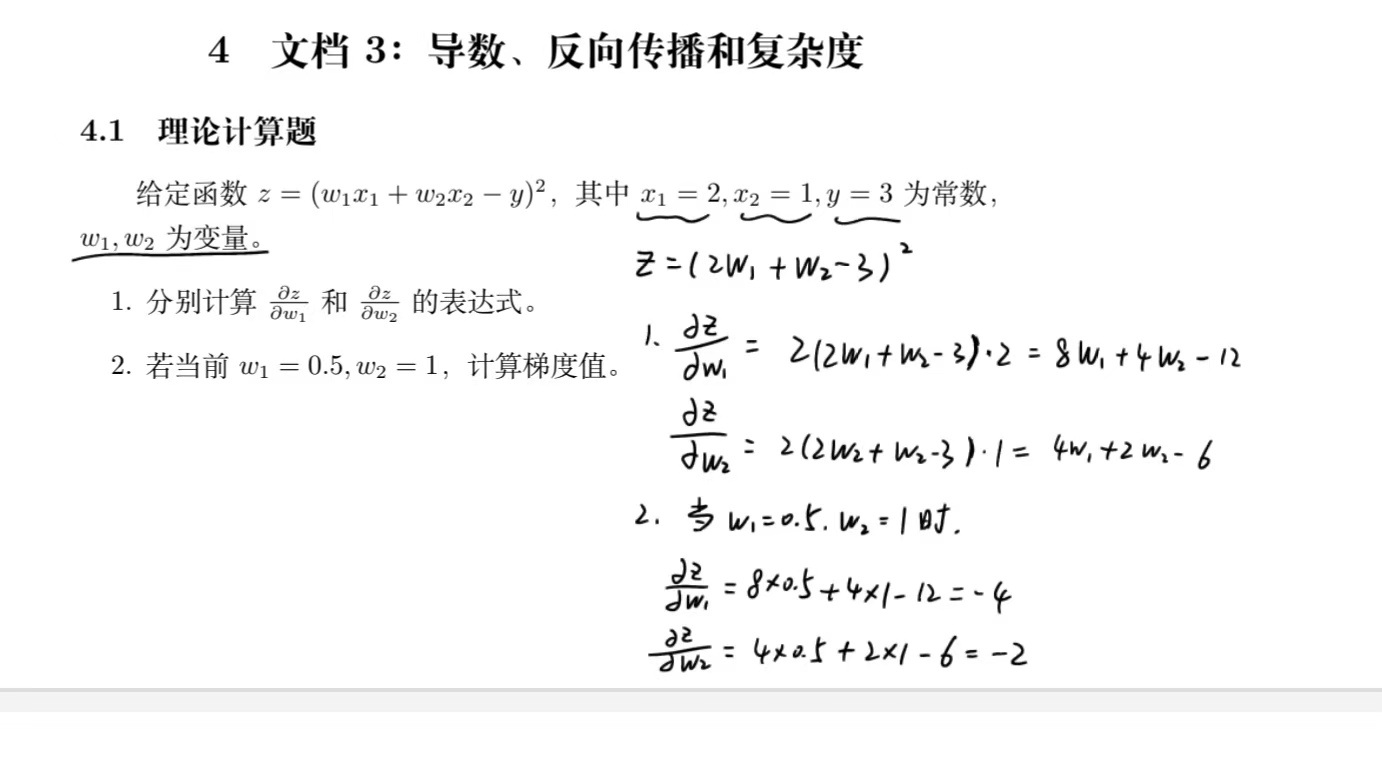

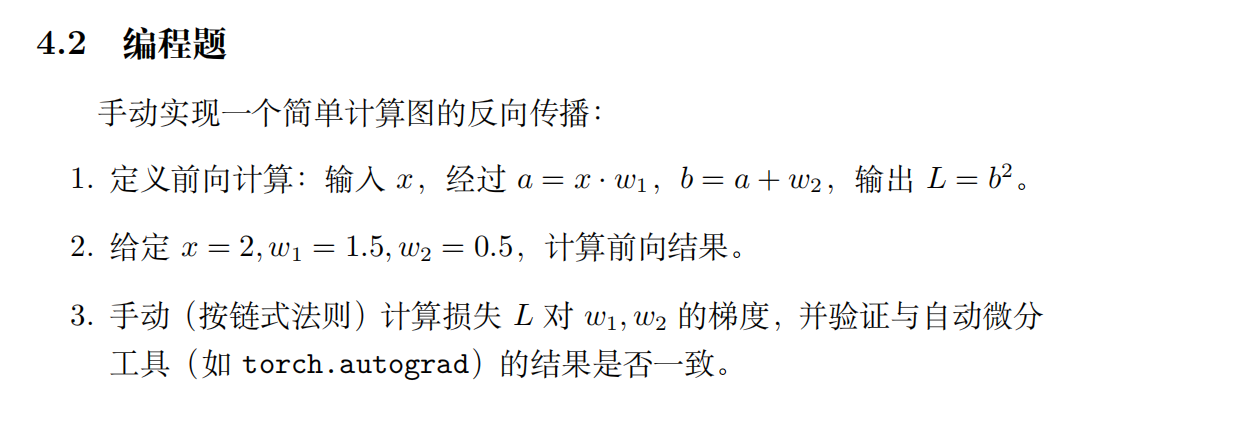

In [8]:
import torch
x = torch.tensor(2.0, requires_grad=False)
w1 = torch.tensor(1.5, requires_grad=True)
w2 = torch.tensor(0.5, requires_grad=True)
a = x * w1
b = a + w2
L = b **2
L.backward()
print(w1.grad.item(), w2.grad.item()) # 输出14.0 7.0

14.0 7.0


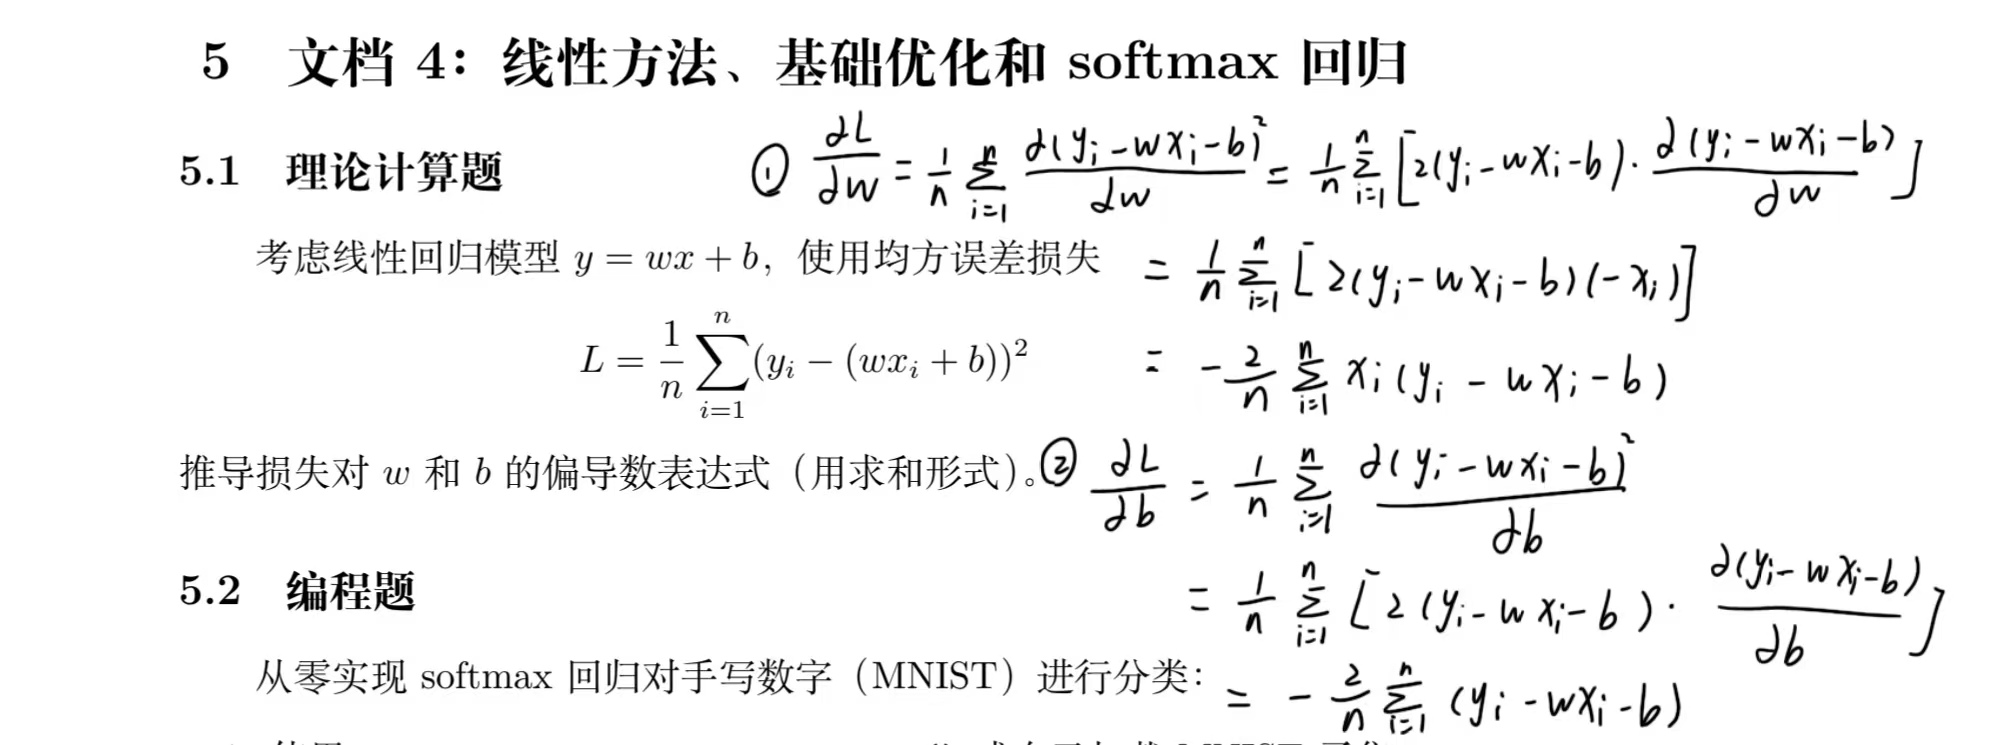

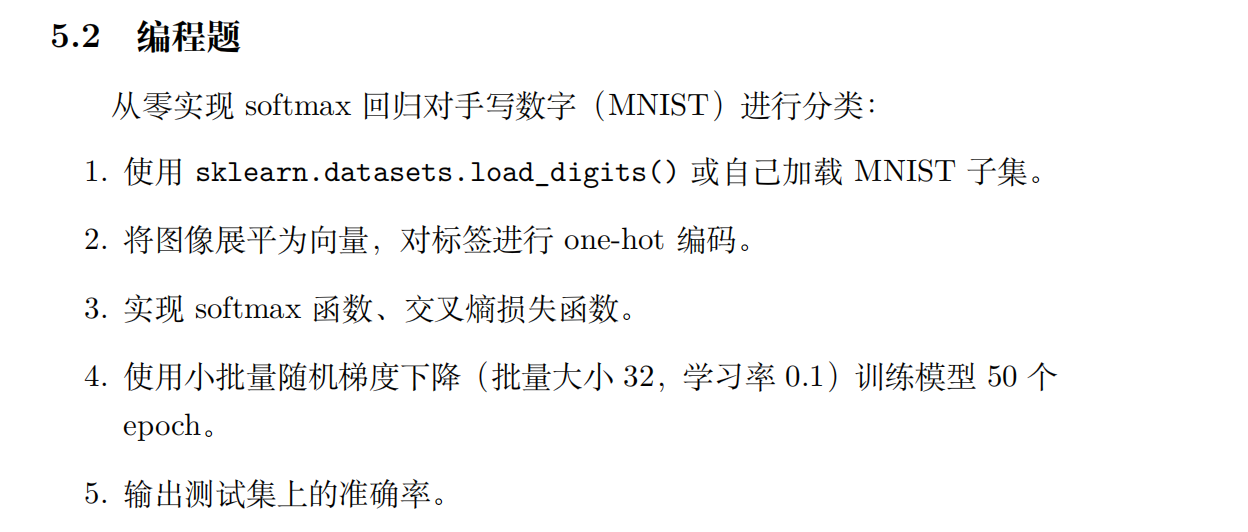

In [9]:
from sklearn.datasets import load_digits
import numpy as np

data = load_digits()
X = data.data / 16.0
y = data.target

def one_hot(y, n_class=10):
    return np.eye(n_class)[y]

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy(y_pred, y_true):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))

# 初始化
W = np.random.randn(64,10)*0.01
b = np.zeros(10)
lr = 0.1
epochs = 50
batch_size =32

for epoch in range(epochs):
    for i in range(0, len(X), batch_size):
        Xb = X[i:i+batch_size]
        yb = y[i:i+batch_size]
        yb_onehot = one_hot(yb)
        
        logits = Xb @ W + b
        y_pred = softmax(logits)
        loss = cross_entropy(y_pred, yb_onehot)
        
        # 梯度
        dW = Xb.T @ (y_pred - yb_onehot) / len(Xb)
        db = np.mean(y_pred - yb_onehot, axis=0)
        
        W -= lr*dW
        b -= lr*db

# 测试
logits = X @ W + b
pred = np.argmax(softmax(logits), axis=1)
acc = np.mean(pred == y)
print("准确率:", acc)

准确率: 0.9688369504730105


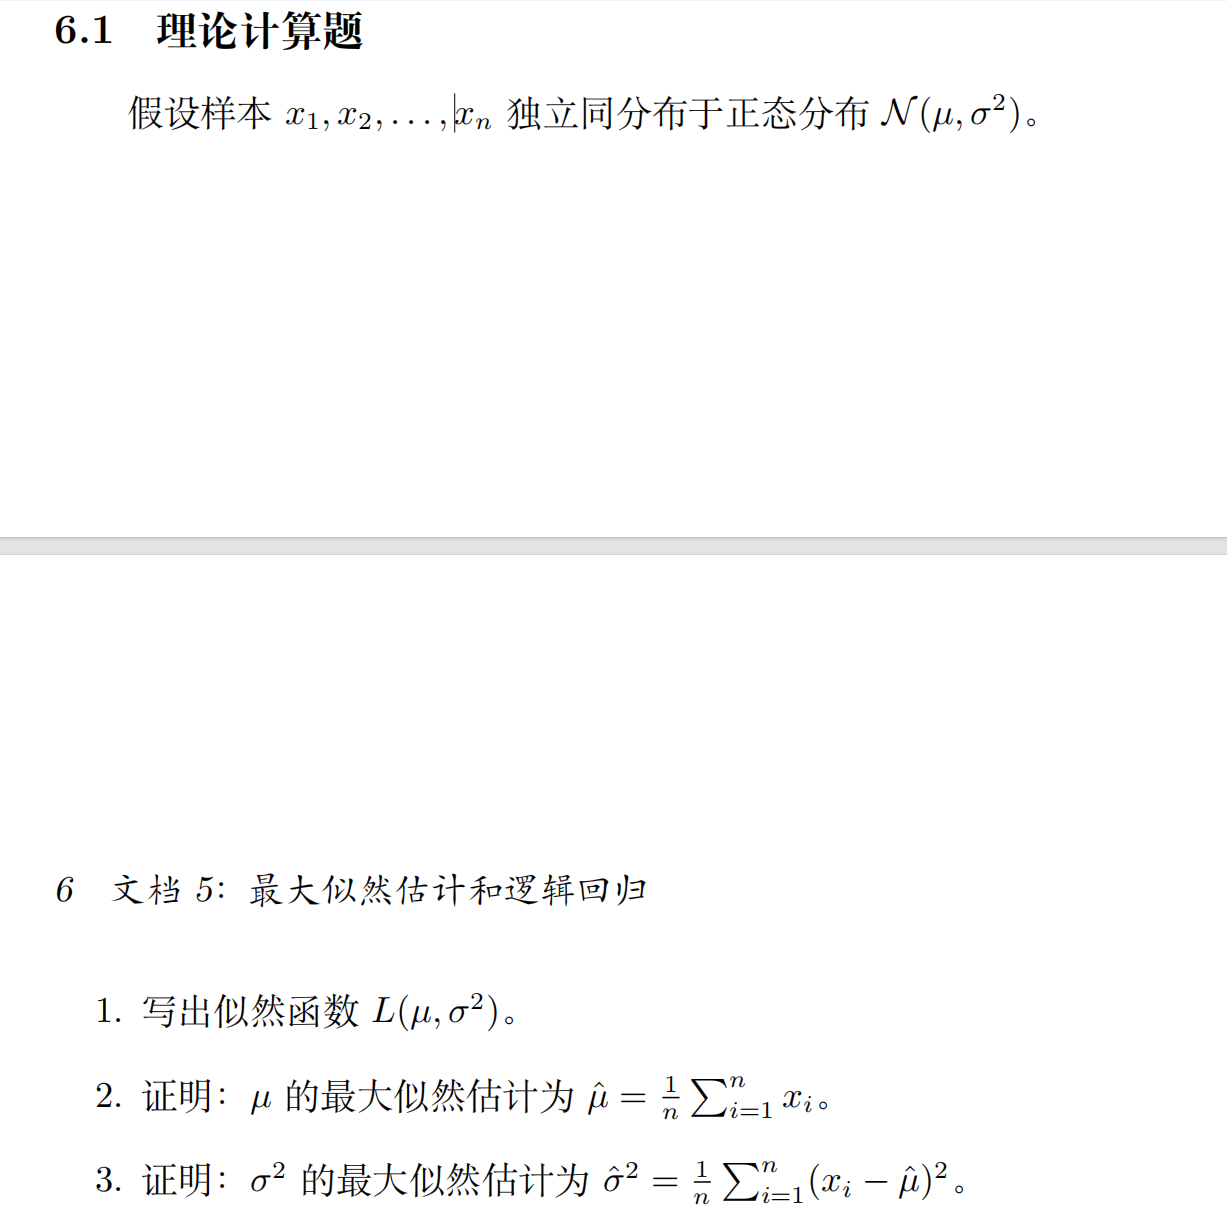

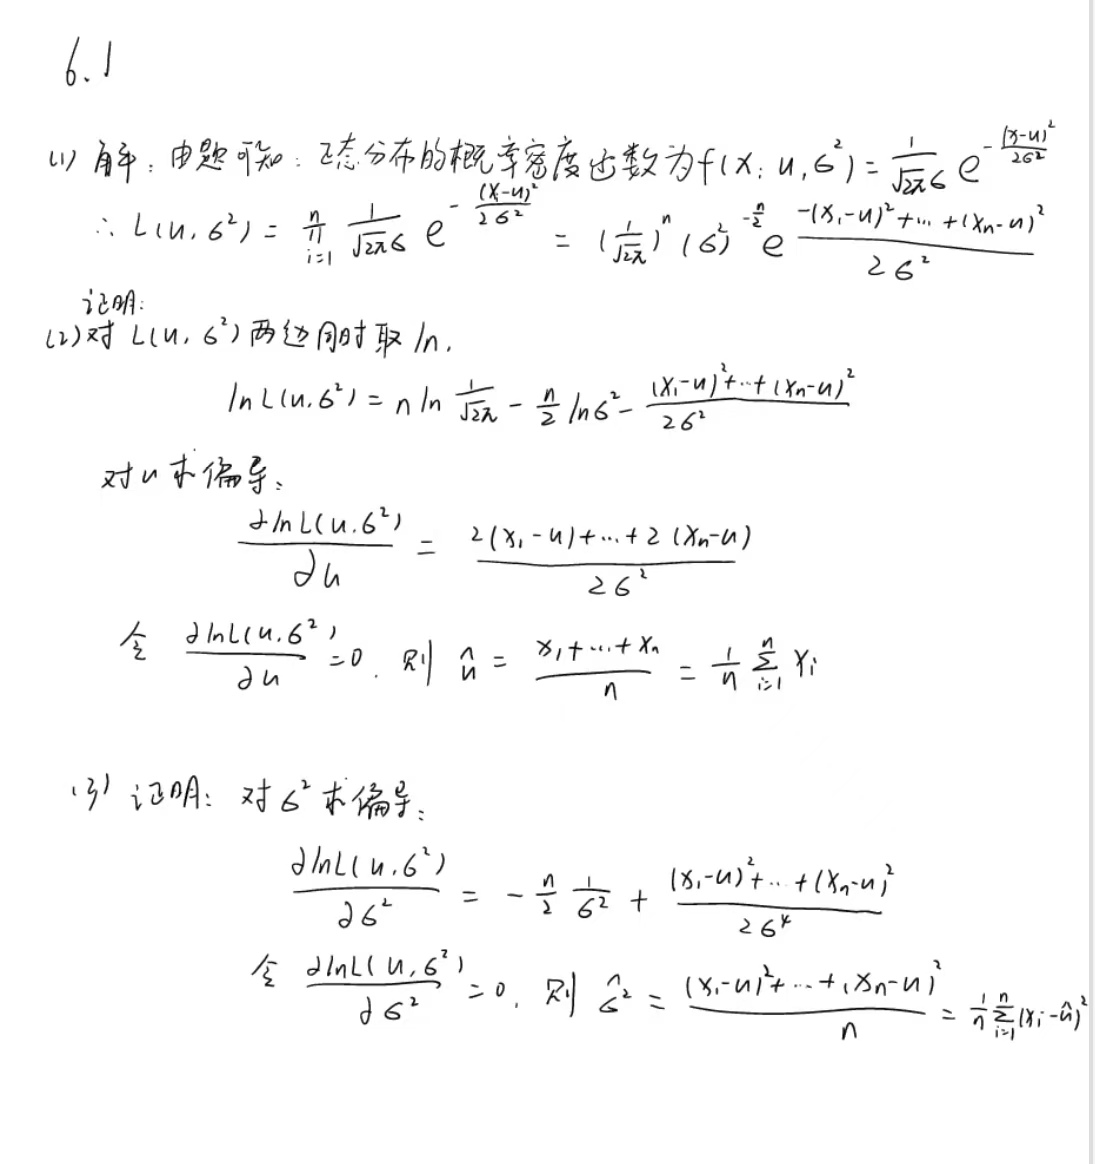

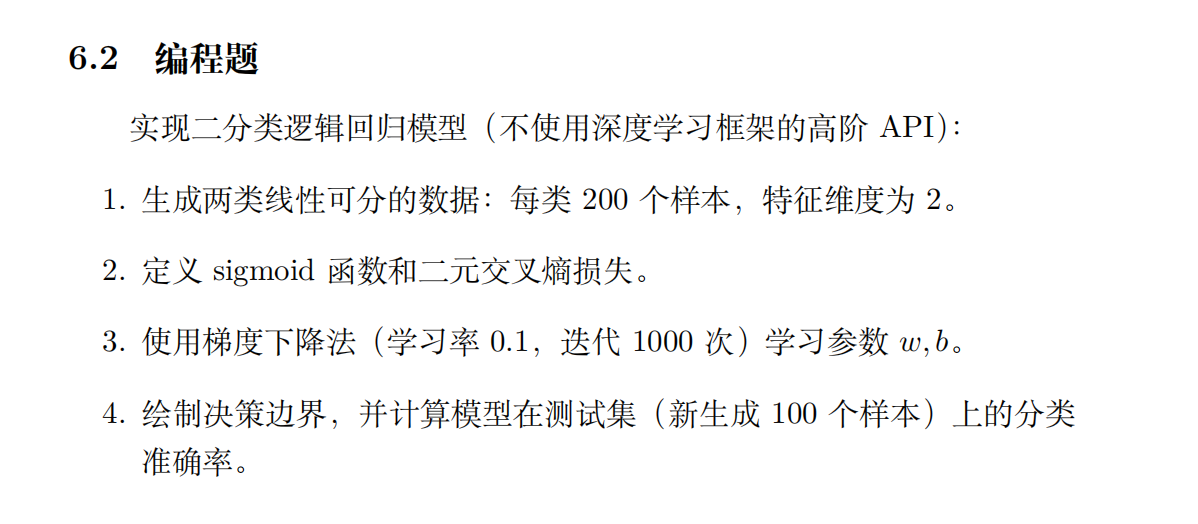

测试准确率: 1.0


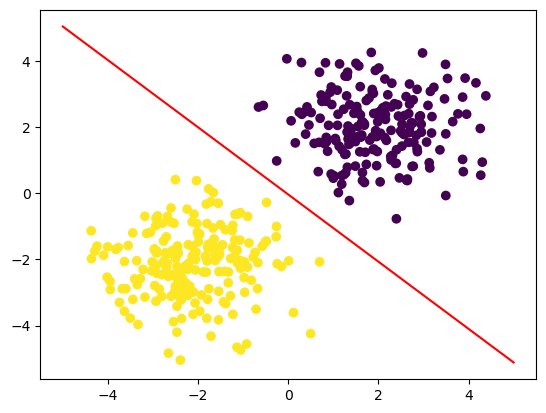

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 生成数据
np.random.seed(0)
n = 200
X0 = np.random.randn(n,2) + [2,2]
X1 = np.random.randn(n,2) + [-2,-2]
X = np.vstack([X0,X1])
y = np.hstack([np.zeros(n), np.ones(n)])

def sigmoid(z):
    return 1/(1+np.exp(-z))

def loss(y_pred, y_true):
    return -np.mean(y_true*np.log(y_pred+1e-8)+(1-y_true)*np.log(1-y_pred+1e-8))

w = np.zeros(2)
b = 0
lr =0.1
iter=1000

for _ in range(iter):
    y_pred = sigmoid(X @ w + b)
    dw = X.T @ (y_pred - y)/len(X)
    db = np.mean(y_pred - y)
    w -= lr*dw
    b -= lr*db

# 测试
X_test = np.vstack([np.random.randn(50,2)+[2,2], np.random.randn(50,2)+[-2,-2]])
y_test = np.hstack([np.zeros(50),np.ones(50)])
pred_test = (sigmoid(X_test @w +b) >0.5).astype(int)
acc = np.mean(pred_test == y_test)
print("测试准确率:", acc)

# 画决策边界
plt.scatter(X[:,0],X[:,1],c=y)
x1 = np.linspace(-5,5,100)
x2 = -(w[0]*x1 +b)/w[1]
plt.plot(x1,x2,'r')
plt.show()